In [374]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils import *
import numpy as np
import hyperspy.api as hs
import os
import matplotlib.pyplot as plt
import copy
from importlib import reload
from EDX import *
from skimage import data, img_as_float
from skimage import feature
import tensorstore as ts
from scipy.stats import pearsonr

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [173]:
def brighten_linear(img, alpha=1.0, beta=30):
    """Increase mean brightness of a grayscale image."""
    img_new = alpha * img + beta
    img_new = np.clip(img_new, 0, 255) 
    return img_new.astype(np.uint8)

### Load all haadf images to inspect drift

In [59]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# load and preprocess
edx, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame=False)
#tile = EM_EDX(haadf, edx, xray_energies)
#tile.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
#tile.apply("binning", parameters={"dim": (1024, 1024, 250)})
#tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})

print(haadf.shape)
print(haadf.max())

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


(100, 2048, 2048)
65535.0


### Get and plot edges from different frames

Text(0.5, 1.0, 'Thresholded HAADF overlap (frame 07 and 08)')

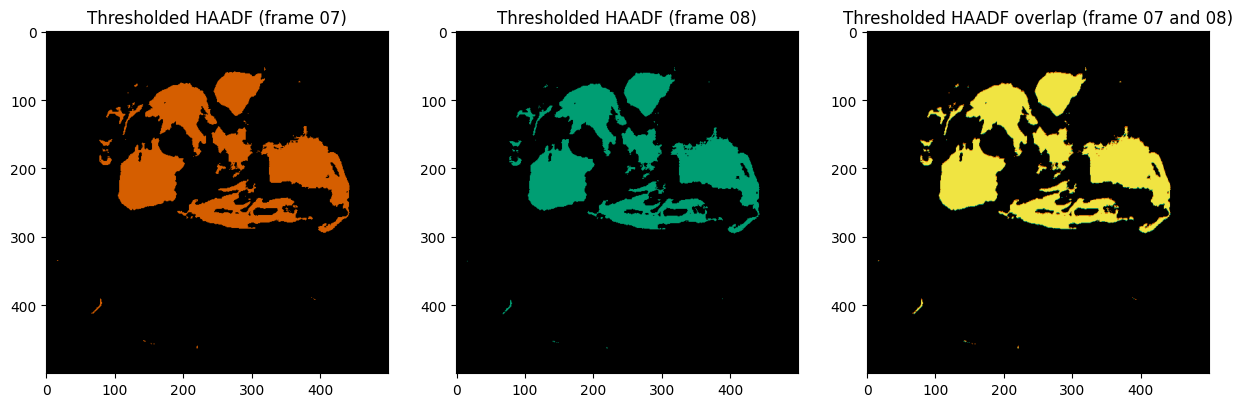

In [353]:
# colorblind colors
colors_cb = {
    "red":    {"hex": "#D55E00", "rgb": (213, 94, 0)},
    "green":  {"hex": "#009E73", "rgb": (0, 158, 115)},
    "yellow": {"hex": "#F0E442", "rgb": (240, 228, 66)},
}

# threshold
haadf_th = MinMax(haadf)>0.5

# plot range
y1, y2, x1, x2 = [750, 1250, 250, 750] 

# frames 
tmp1, tmp2 = [7, 8]

# binarized images
img1b = haadf_th[tmp1,750:1250,250:750]
img2b = haadf_th[tmp2,750:1250,250:750]
img3b = img1b.astype('uint8') + img2b.astype('uint8')

# img dims
h, w = img1b.shape

# make appropraite images
img1 = np.zeros((h, w, 3), np.uint8)
img2 = np.zeros((h, w, 3), np.uint8)
img3 = np.zeros((h, w, 3), np.uint8)


img1[np.where(img1b)[0],np.where(img1b)[1],:] = colors_cb['red']['rgb']
img2[np.where(img2b)[0],np.where(img2b)[1],:] = colors_cb['green']['rgb']

# overlap image
img3[np.where(img1b)[0],np.where(img1b)[1],:] = colors_cb['red']['rgb']
img3[np.where(img2b)[0],np.where(img2b)[1],:] = colors_cb['green']['rgb']
img3[np.where(img3b==2)[0],np.where(img3b==2)[1],:] = colors_cb['yellow']['rgb']


# plot
f, ax = plt.subplots(1,3,figsize=(15,10))
ax[0].imshow(img1)
ax[0].set_title('Thresholded HAADF (frame %02d)' % tmp1)
ax[1].imshow(img2)
ax[1].set_title('Thresholded HAADF (frame %02d)' % tmp2)
ax[2].imshow(img3)
ax[2].set_title('Thresholded HAADF overlap (frame %02d and %02d)' % (tmp1,tmp2))



#ax[1].imshow(feature.canny(haadf_th[0,750:1250,250:750],sigma=0.8),cmap='gray')
#ax[0].title('Thresholded HAADF')

## SOFIMA
- !pip install git+https://github.com/google-research/sofima
- demo: https://colab.research.google.com/github/google-research/sofima/blob/main/notebooks/em_alignment.ipynb#scrollTo=AZvmtg0TTBAJ
- Trying to match the google colab demo

In [328]:
# channels to align
n_channels = 20


# Reorder to (2048, 2048, 100)- and limit to 20 frames
data_1x = haadf.transpose(1, 2, 0)[..., None]
data_1x = data_1x[:,:,:n_channels,:]


# create a binned version (also to match the unaligned 2x 
data_2x = np.zeros((1024,1024,n_channels,1)) 

for i in range(data_2x.shape[2]):
    data_2x[:,:,i,0] = binning_xy(data_1x[:,:,i,:].squeeze())


# convert both sets of images to 0-255, channel wise

for i in range(data_2x.shape[2]):
    data_1x[:,:,i,0] = Normalize_uint8(data_1x[:,:,i,0],normalize_by=data_1x[:,:,:,0])
    data_2x[:,:,i,0] = Normalize_uint8(data_2x[:,:,i,0],normalize_by=data_2x[:,:,i,0])

data_1x = data_1x.astype('uint8')
data_2x = data_2x.astype('uint8')


# optional (this didn't increase the flow values)
#data_1x =  brighten_linear(data_1x, alpha=1.0, beta=50)
#data_2x =  brighten_linear(data_2x, alpha=1.0, beta=50)



# Create the TensorStore objects 
unaligned_1x = ts.open({
    'driver': 'n5',
    'kvstore': {
         'driver': 'file',
         'path': 'tmp/dataset1/',
     },
     'metadata': {
         'compression': {
             'type': 'gzip'
         },
         'dataType': 'uint8',
         'dimensions': data_1x.shape,
         'blockSize': [100, 100, 1, 1],
     },
     'create': True,
     'delete_existing': True,}).result()

unaligned_2x = ts.open({
    'driver': 'n5',
    'kvstore': {
         'driver': 'file',
         'path': 'tmp/dataset2/',
     },
     'metadata': {
         'compression': {
             'type': 'gzip'
         },
         'dataType': 'uint8',
         'dimensions': data_2x.shape,
         'blockSize': [50, 50, 1, 1],
     },
     'create': True,
     'delete_existing': True,}).result()

write_future = unaligned_1x.write(data_1x)
write_future.result()
write_future = unaligned_2x.write(data_2x)
write_future.result()


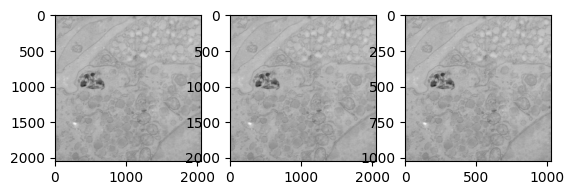

In [329]:
f, ax = plt.subplots(1,3)
tmp_c = 15
ax[0].imshow(haadf[tmp_c,:,:],cmap='gray_r')
ax[1].imshow(unaligned_1x[:,:,tmp_c,0],cmap='gray_r')
ax[2].imshow(unaligned_2x[:,:,tmp_c,0],cmap='gray_r')


#### check dims

In [330]:
print('Full res set stats:')
print(unaligned_1x.shape)
print(unaligned_1x[:,:,:,:].read().result().min())
print(unaligned_1x[:,:,:,:].read().result().max())
print(unaligned_2x[:,:,:,:].read().result().mean())
print(unaligned_1x[:,:,:,:].read().result().dtype)

print('Reduced res set stats:')
print(unaligned_2x.shape)
print(unaligned_2x[:,:,:,:].read().result().min())
print(unaligned_2x[:,:,:,:].read().result().max())
print(unaligned_2x[:,:,:,:].read().result().mean())
print(unaligned_2x[:,:,:,:].read().result().dtype)


Full res set stats:
(2048, 2048, 20, 1)
0
255
83.78087391853333
uint8
Reduced res set stats:
(1024, 1024, 20, 1)
0
255
83.78087391853333
uint8


#### sofima imports

In [270]:
from concurrent import futures
import time

# 
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import jax
print(jax.default_backend()) 

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from connectomics.common import bounding_box
from sofima import flow_field
from sofima import flow_utils
from sofima import map_utils
from sofima import mesh
from sofima import warp
from tqdm.notebook import tqdm

cpu


#### check what jax is running on
- Maybe can use mps later, but 'cpu' is fast enough.

In [ ]:
# set to cpu
# jax.default_backend()

### Flow field estimation (from demo)

First, we calculate the flow fields between the current section and the directly preceding section. Flow fields can also be computed between pairs of sections that are not directly adjacent. This is useful if sections are incomplete or missing, but is not something we have to worry about in this demo.

#### My notes:
- Do we need any change of parameters? Probably patch_size and stride

In [331]:
# Both of the settings below are expressed in pixels.
patch_size = 100  # XY spatial context used for flow field estimation
stride = 25  # XY distance between centers of adjacent patches.

def _compute_flow(volume):
  mfc = flow_field.JAXMaskedXCorrWithStatsCalculator()
  flows = []
  prev = volume[..., 0, 0].T.read().result()

  fs = []
  with futures.ThreadPoolExecutor() as tpe:
    # Prefetch the next sections to memory so that we don't have to wait for them
    # to load when the GPU becomes available.
    for z in range(1, unaligned_1x.shape[2]):
      fs.append(tpe.submit(lambda z=z: volume[..., z, 0].T.read().result()))

    fs = fs[::-1]

    for z in tqdm(range(1, unaligned_1x.shape[2])):
      curr = fs.pop().result()

      # The batch size is a parameter which impacts the efficiency of the computation (but
      # not its result). It has to be large enough for the computation to fully utilize the
      # available GPU capacity, but small enough so that the batch fits in GPU RAM.
      flows.append(mfc.flow_field(prev, curr, (patch_size, patch_size),
                                  (stride, stride), batch_size=256))
      prev = curr

  return flows

#### From collab: 
Compute flows at native and 2x reduced in-plane resolution. The lower resolution flow has reduced precision, but is helpful for providing approximate flow vectors in places where the full-resolution flow might be impossible to estimate, e.g. in the interior of cell bodies or blood vessels.


In [332]:
flows1x_og = np.array(_compute_flow(unaligned_1x))
flows2x_og = np.array(_compute_flow(unaligned_2x))

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

### Notes:
- check the dimensions of the flows1x and flows2x (and the collab note below)

In [333]:
# check dims
print(flows1x_og.shape,flows2x_og.shape)
# check nan values
print(np.isnan(flows1x_og).sum(),np.isnan(flows1x_og).sum())


(19, 4, 78, 78) (19, 4, 37, 37)
0 0


#### From collab:
The flow fields generated in the previous step are 4-channel arrays, where the first two channels store the XY components of the flow vector, and the two remaining channels are measures of estimation quality (see `sofima.flow_field._batched_peaks` for more info).

In [334]:
# Convert to [channels, z, y, x].
flows2x = np.transpose(flows2x_og, [1, 0, 2, 3])
flows1x = np.transpose(flows1x_og, [1, 0, 2, 3])

# Pad to account for the edges of the images where there is insufficient context to estimate flow.
pad = patch_size // 2 // stride
flows1x = np.pad(flows1x, [[0, 0], [0, 0], [pad, pad], [pad, pad]], constant_values=np.nan)
flows2x = np.pad(flows2x, [[0, 0], [0, 0], [pad, pad], [pad, pad]], constant_values=np.nan)

# check dim
print(flows1x.shape,flows2x.shape)
# check nan values
print(np.isnan(flows1x).sum(),np.isnan(flows1x).sum())
print("Ratio of NaN: ", np.isnan(flows1x).sum()/flows1x.size ,np.isnan(flows2x).sum()/flows2x.size)

(4, 19, 82, 82) (4, 19, 41, 41)
48640 48640
Ratio of NaN:  0.09518143961927424 0.18560380725758477


#### Note on above:
The padded values are NaN. Nothing else thus far.

#### From collab:
We now remove uncertain flow estimates by replacing them with NaNs, and merge the two flow arrays into a single flow field at full resolution. In a distributed environment, this step would be done with the ReconcileAndFilterFlows processor.

#### My notes:
- With default (collab) parameters of clean_flow, everything is uncertain. Must modify.
- Either that, or the values at this point have been miscalculated. No default values in the function itself.
- possible hint here: https://github.com/google-research/sofima/issues/3

In [335]:
#f1 = flow_utils.clean_flow(flows1x, min_peak_ratio=1.6, min_peak_sharpness=1.6, max_magnitude=80, max_deviation=20)
#f2 = flow_utils.clean_flow(flows2x, min_peak_ratio=1.6, min_peak_sharpness=1.6, max_magnitude=80, max_deviation=20)

f1 = flow_utils.clean_flow(flows1x, min_peak_ratio=1.1, min_peak_sharpness=1.1, max_magnitude=0, max_deviation=0)
f2 = flow_utils.clean_flow(flows2x, min_peak_ratio=1.1, min_peak_sharpness=1.1, max_magnitude=0, max_deviation=0)

#f1 = flow_utils.clean_flow(flows1x, min_peak_ratio=1.6, min_peak_sharpness=1.6, max_magnitude=50, max_deviation=20)
#f2 = flow_utils.clean_flow(flows2x, min_peak_ratio=1.6, min_peak_sharpness=1.6, max_magnitude=50, max_deviation=20)

# check dim
#print(flows1x.shape,flows2x.shape)
# check nan values
print(np.isnan(flows1x).sum(),np.isnan(flows1x).sum())
print("Ratio of NaN before: ", np.isnan(flows1x).sum()/flows1x.size ,np.isnan(flows2x).sum()/flows2x.size)
print("Ratio of NaN after: ", np.isnan(f1).sum()/f1.size ,np.isnan(f2).sum()/f2.size)

48640 48640
Ratio of NaN before:  0.09518143961927424 0.18560380725758477
Ratio of NaN after:  0.09949434860202261 0.1860734525188641


In [336]:
print(flows1x.shape)
print(f1.shape)

(4, 19, 82, 82)
(2, 19, 82, 82)


#### From collab:
Plot the horizontal component of the flow vector, before (left) and after (right) filtering. While blobs indicate areas where uncertain flow estimates were removed.

#### Notes on below:
- tmp1 (0, 1) horizontal and vertical flow.
- tmp2 (n_channels-1, i.e. 19) is the flow between this channel and the one before it, so tmp2 =0 is the flow of the second haadf w.r.t the first, and tmp2 = 2 is the flow of the third w.r.t. to the second. And the flow diagrams make sense considering the observed drift in the haadfs.
- Considering this, the logic doesn't fully align (pun-intended) with our goal. We need to match each frame with a reference, not with the one before it. But if you 

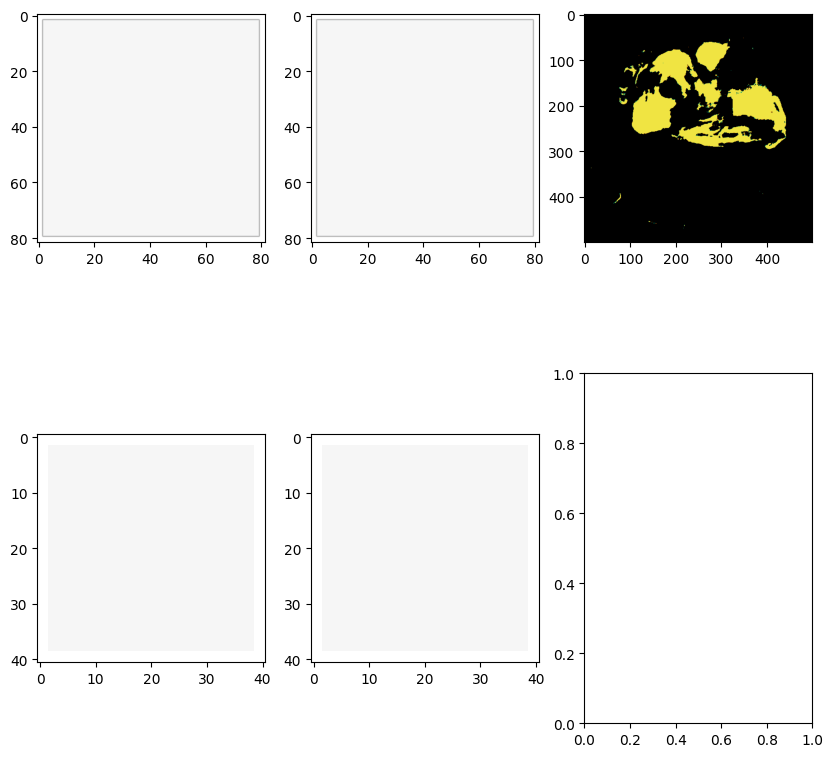

In [358]:
tmp1, tmp2 = 0, 9
f, ax = plt.subplots(2, 3, figsize=(10, 10))
ax[0][0].imshow(flows1x[tmp1, tmp2, ...], cmap=plt.cm.RdBu, vmin=-10, vmax=10)
ax[0][1].imshow(f1[tmp1, tmp2, ...], cmap=plt.cm.RdBu, vmin=-10, vmax=10)
ax[1][0].imshow(flows2x[tmp1, tmp2, ...], cmap=plt.cm.RdBu, vmin=-10, vmax=10)
ax[1][1].imshow(f2[tmp1, tmp2, ...], cmap=plt.cm.RdBu, vmin=-10, vmax=10)

# reference

# binarized images
img1b = haadf_th[tmp2+1,750:1250,250:750]
img2b = haadf_th[tmp2,750:1250,250:750]
img3b = img1b.astype('uint8') + img2b.astype('uint8')

# img dims
h, w = img1b.shape
# overlap image
img3 = np.zeros((h, w, 3), np.uint8)
img3[np.where(img1b)[0],np.where(img1b)[1],:] = colors_cb['red']['rgb']
img3[np.where(img2b)[0],np.where(img2b)[1],:] = colors_cb['green']['rgb']
img3[np.where(img3b==2)[0],np.where(img3b==2)[1],:] = colors_cb['yellow']['rgb']
ax[0][2].imshow(img3)

In [361]:
from scipy import interpolate
f2_hires = np.zeros_like(f1)

scale = 0.5
oy, ox = np.ogrid[:f2.shape[-2], :f2.shape[-1]]
oy = oy.ravel() / scale
ox = ox.ravel() / scale

box1x = bounding_box.BoundingBox(start=(0, 0, 0), size=(f1.shape[-1], f1.shape[-2], 1))
box2x = bounding_box.BoundingBox(start=(0, 0, 0), size=(f2.shape[-1], f2.shape[-2], 1))

for z in tqdm(range(f2.shape[1])):
  # Upsample and scale spatial components.
  resampled = map_utils.resample_map(
      f2[:, z:z + 1, ...],  #
      box2x, box1x, 1 / scale, 1)
  f2_hires[:, z:z + 1, ...] = resampled / scale

  0%|          | 0/19 [00:00<?, ?it/s]

In [362]:
final_flow = flow_utils.reconcile_flows((f1, f2_hires), max_gradient=0, max_deviation=20, min_patch_size=400)

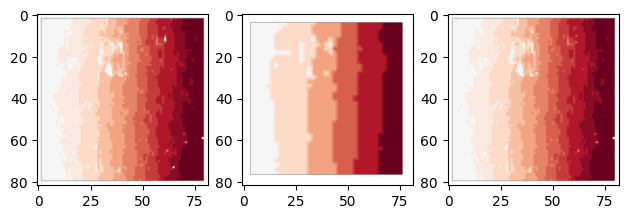

In [368]:
# Plot (left to right): high res. flow, upsampled low res. flow, combined flow to use for alignment.
tmp1, tmp2  = 0, 1
f, ax = plt.subplots(1, 3, figsize=(7.5, 2.5))
ax[0].imshow(f1[tmp1, tmp2, ...], cmap=plt.cm.RdBu,vmin=-10, vmax=10)
ax[1].imshow(f2_hires[tmp1, tmp2, ...], cmap=plt.cm.RdBu,vmin=-10, vmax=10)
ax[2].imshow(final_flow[tmp1, tmp2, ...], cmap=plt.cm.RdBu,vmin=-10, vmax=10)

## Mesh optimization (from collab

We use an elastic mesh optimizer to find a configuration of the imagery that is compatible with the estimated flow field and preserves the original geometry as much as possible.

The optimization proceeds sequentially, section by section. In a distributed environment, this computation can be parallelized across the plane (by independently solving overlapping XY tiles), as well as split into blocks along the Z axis. This makes it possible to scale this process to arbitrarily large volumes. For simplicity, here we solve the complete stack in one go.

In [320]:
config = mesh.IntegrationConfig(dt=0.001, gamma=0.0, k0=0.01, k=0.1, stride=(stride, stride), num_iters=1000,
                                max_iters=100000, stop_v_max=0.005, dt_max=1000, start_cap=0.01,
                                final_cap=10, prefer_orig_order=True)

In [370]:
print(final_flow.shape)

(2, 19, 82, 82)


In [321]:
solved = [np.zeros_like(final_flow[:, 0:1, ...])]
origin = jnp.array([0., 0.])

for z in tqdm(range(0, final_flow.shape[1])):
  prev = map_utils.compose_maps_fast(final_flow[:, z:z+1, ...], origin, stride,
                                     solved[-1], origin, stride)
  x = np.zeros_like(solved[0])
  x, e_kin, num_steps = mesh.relax_mesh(x, prev, config)
  x = np.array(x)
  solved.append(x)

solved = np.concatenate(solved, axis=1)

  0%|          | 0/19 [00:00<?, ?it/s]

## Image warping (from colab):
Image warping requires an inverse coordinate map, so compute that first. In a distributed environment, this can be done with the `InvertMap` processor.

In [371]:
inv_map = map_utils.invert_map(solved, box1x, box1x, stride)

warped = [np.transpose(unaligned_1x[:, :, 0:1, 0].read().result(), [2, 1, 0])]

for z in tqdm(range(1, unaligned_1x.shape[2])):
  data_box = bounding_box.BoundingBox(start=(0, 0, 0), size=(2048, 2048, 1))
  out_box = bounding_box.BoundingBox(start=(0, 0, 0), size=(2048, 2048, 1))

  data = np.transpose(unaligned_1x[data_box.start[0]:data_box.end[0],
                                   data_box.start[1]:data_box.end[1],
                                   z:z+1, 0:1].read().result(), [3, 2, 1, 0])
  warped.append(
      warp.warp_subvolume(data, data_box, inv_map[:, z:z+1, ...], box1x, stride, out_box, 'lanczos', parallelism=1)[0, ...])

  0%|          | 0/19 [00:00<?, ?it/s]

In [372]:
warped_xyz = np.transpose(np.concatenate(warped, axis=0), [2, 1, 0])
print(warped_xyz.shape)

(2048, 2048, 20)


## From collab:
- Render an XZ cross section to check the quality of the alignment visually

## Notes:
- We can't do that, we don't have a volume here. Let's do something else. Our wrapped xyz should correspond to xyc, if all was ok.

In [381]:
i = 0
pearsonr(warped_xyz[:,:,0].ravel(),warped_xyz[:,:,i].ravel())

PearsonRResult(statistic=np.float64(0.9999999999999748), pvalue=np.float64(0.0))

AttributeError: 'tensorstore.TensorStore' object has no attribute 'ravel'

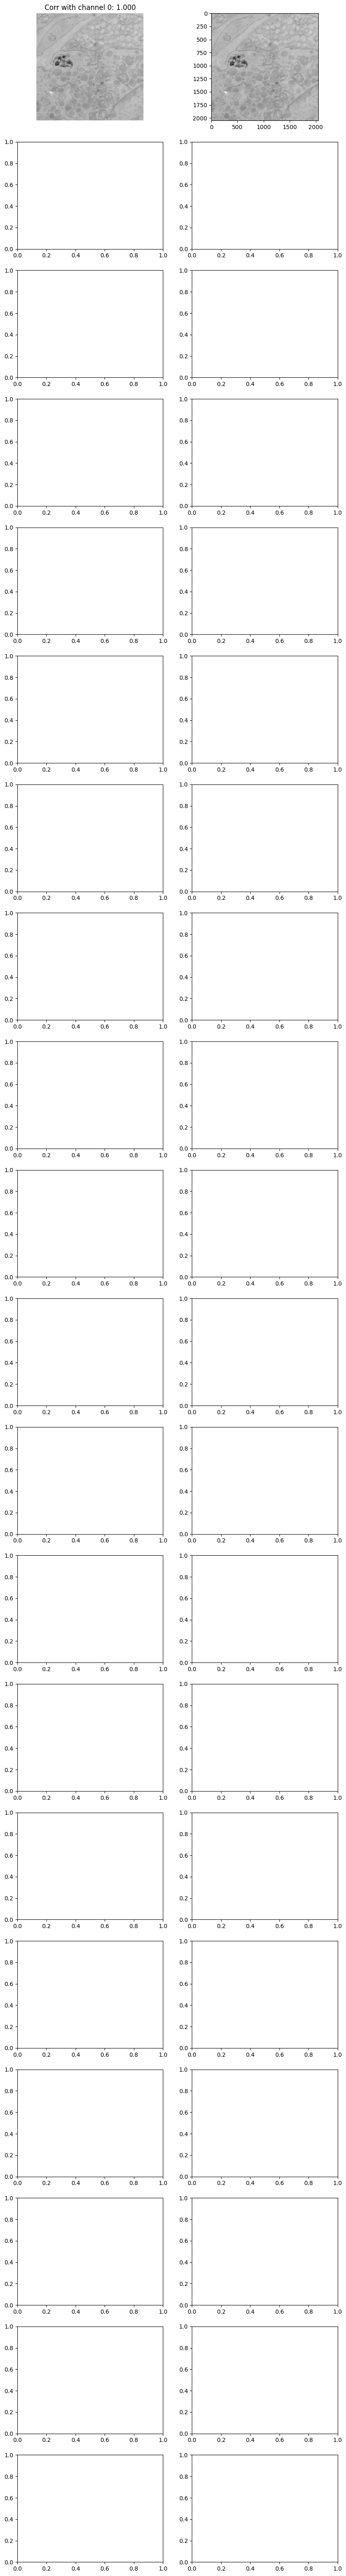

In [382]:
f, ax = plt.subplots(20,2, figsize=(10,80))
for i in range(20):
    ax[i][0].imshow(warped_xyz[:,:,i],cmap='gray_r')
    ax[i][0].set_title('Corr with channel 0: %.3f' % pearsonr(warped_xyz[:,:,0].ravel(),warped_xyz[:,:,i].ravel())[0])
    ax[i][0].axis('off')
    
    ax[i][1].imshow(unaligned_1x[:,:,i,0],cmap='gray_r')
    coeff_after = pearsonr(unaligned_1x[:,:,0,0].read().result().ravel(),unaligned_1x[:,:,i,0].read().result().ravel())[0]
    ax[i][1].set_title('Corr with channel 0: %.3f' % coeff_after)
    ax[i][1].axis('off')
    